# PyTorch Image Classification

## Setup

In [18]:
# Set up Kaggle API credentials for downloading datasets
import os  # For file and directory operations
import shutil  # For file copying

kaggle_json_path = './kaggle.json'  # Path to your Kaggle API key
kaggle_dir = os.path.expanduser('~/.kaggle')  # Default Kaggle directory
os.makedirs(kaggle_dir, exist_ok=True)  # Create directory if it doesn't exist
shutil.copy(kaggle_json_path, os.path.join(kaggle_dir, 'kaggle.json'))  # Copy API key
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)  # Set permissions
print('Kaggle API key set up successfully.')

Kaggle API key set up successfully.


In [19]:
# Install and import opendatasets, then download the animal faces dataset from Kaggle
!pip install opendatasets --quiet  # Install opendatasets if not already installed
import opendatasets as od  # Import opendatasets for easy dataset download
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")  # Download dataset

Skipping, found downloaded files in ".\animal-faces" (use force=True to force download)


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


## Imports

In [20]:
# Import required libraries and set device
import torch  # PyTorch main package
import torch.nn as nn  # Neural network layers
from torch.optim import Adam  # Optimizer
from torch.utils.data import Dataset, DataLoader  # Dataset and DataLoader utilities
from sklearn.preprocessing import LabelEncoder  # For encoding string labels
import numpy as np  # Numerical operations
from torchvision import transforms  # Image transformations
import matplotlib.pyplot as plt  # Plotting
from torchsummary import summary  # Model summary utility
torch.manual_seed(42)  # For reproducibility
import pandas as pd  # Data manipulation
from PIL import Image  # Image processing

# Set device to GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.9.1+rocm7.2.1
Using device: cuda


## Image data classification with PyTorch

In [21]:
# Collect image file paths and labels from the dataset directory
image_path = []
labels = []

# Loop through each split (train/val) and each class (cat/dog/wild)
for i in os.listdir('animal-faces/afhq'):
    for label in os.listdir(f'animal-faces/afhq/{i}'):
        for img in os.listdir(f'animal-faces/afhq/{i}/{label}'):
            image_path.append(f'animal-faces/afhq/{i}/{label}/{img}')  # Store image path
            labels.append(label)  # Store label
            
# Create a DataFrame with image paths and labels
data_df = pd.DataFrame(zip(image_path, labels), columns=['image_path', 'label'])
print(data_df["label"].unique()) 
data_df.head()

['cat' 'dog' 'wild']


,image_path,label
0,animal-faces/afhq/train/cat/flickr_cat_000002.jpg,cat
1,animal-faces/afhq/train/cat/flickr_cat_000003.jpg,cat
2,animal-faces/afhq/train/cat/flickr_cat_000004.jpg,cat
3,animal-faces/afhq/train/cat/flickr_cat_000005.jpg,cat
4,animal-faces/afhq/train/cat/flickr_cat_000006.jpg,cat


In [22]:
# Split the data into train, validation, and test sets
train = data_df.sample(frac=0.7, random_state=42)  # 70% for training
test = data_df.drop(train.index)  # Remaining 30%

val = test.sample(frac=0.5, random_state=42)  # Half of remaining for validation
test = test.drop(val.index)  # The rest for testing

print(f"Train size: {len(train)}, Val size: {len(val)}, Test size: {len(test)}")

Train size: 11291, Val size: 2420, Test size: 2419


In [23]:
# Encode string labels to integers
label_encoder = LabelEncoder()
label_encoder.fit(data_df["label"])

# Define image transformations for preprocessing
# - Resize images to 128x128
# - Convert images to PyTorch tensors
# - Ensure tensor dtype is float
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
])

In [24]:
# Custom PyTorch Dataset for loading images and labels
class CustomImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df  # DataFrame with image paths and labels
        self.transform = transform  # Image transformations
        # No need to pre-encode all labels; handle per sample
    def __len__(self):
        return len(self.df)  # Return number of samples
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']  # Get image path
        label = self.df.iloc[idx]['label']  # Get label (string)
        
        image = Image.open(img_path).convert('RGB')  # Load and convert image to RGB
        
        if self.transform:
            image = self.transform(image)  # Apply transformations
        
        label = label_encoder.transform([label])[0]  # Encode label as integer
        label = torch.tensor(label, dtype=torch.long)  # Ensure label is torch.long for CrossEntropyLoss
        return image, label  # Return image and label as a tuple

In [25]:
train_dataset = CustomImageDataset(df = train, transform=transform)  # Create training dataset
val_dataset = CustomImageDataset(df = val, transform=transform)  # Create validation dataset
test_dataset = CustomImageDataset(df = test, transform=transform)  # Create test dataset

In [26]:
train_dataset.__getitem__(0)  # Test getting the first item from the training dataset


(tensor([[[0.6588, 0.6510, 0.6078,  ..., 0.4863, 0.5020, 0.4784],
          [0.5608, 0.6196, 0.6588,  ..., 0.5490, 0.5490, 0.5137],
          [0.5059, 0.5608, 0.6118,  ..., 0.5843, 0.5647, 0.5373],
          ...,
          [0.5529, 0.5608, 0.5686,  ..., 0.3725, 0.3529, 0.3686],
          [0.5569, 0.5569, 0.5647,  ..., 0.3725, 0.3725, 0.3922],
          [0.5176, 0.5098, 0.5137,  ..., 0.4392, 0.4392, 0.4471]],
 
         [[0.6588, 0.6588, 0.6235,  ..., 0.5255, 0.5882, 0.6000],
          [0.5686, 0.6157, 0.6353,  ..., 0.6000, 0.6431, 0.6392],
          [0.5255, 0.5608, 0.5961,  ..., 0.6588, 0.6745, 0.6745],
          ...,
          [0.5529, 0.5608, 0.5686,  ..., 0.3255, 0.3098, 0.3255],
          [0.5569, 0.5569, 0.5647,  ..., 0.3255, 0.3255, 0.3490],
          [0.5373, 0.5333, 0.5333,  ..., 0.3882, 0.3922, 0.4000]],
 
         [[0.5412, 0.5020, 0.4118,  ..., 0.2941, 0.3569, 0.3647],
          [0.4431, 0.4824, 0.4902,  ..., 0.3608, 0.3765, 0.3490],
          [0.3373, 0.3843, 0.4275,  ...,

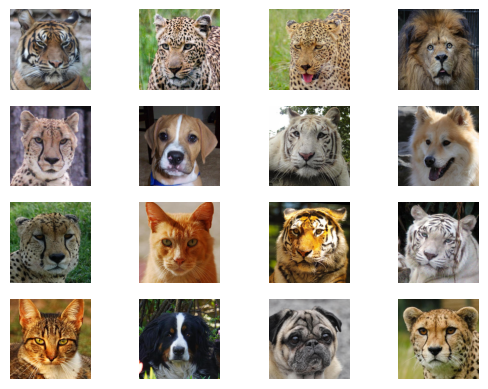

In [47]:
n_rows = 4
n_cols = 4

f, axarr = plt.subplots(n_rows, n_cols)  # Create a grid of subplots

for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB") # Randomly sample an image path
        axarr[row, col].imshow(image)  # Display the image in the subplot
        axarr[row, col].axis('off')  # Hide axes
plt.show()  # Show the plot with sample images

In [28]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [29]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # Create DataLoader for training
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)  # Create DataLoader for validation
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)  # Create DataLoader for testing

In [30]:
class Net(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.conv1 = nn.Conv2d(3,32, kernel_size=3, padding=1)  # First convolutional layer
        self.conv2 = nn.Conv2d(32,64, kernel_size=3, padding=1)  # Second convolutional layer
        self.conv3 = nn.Conv2d(64,128, kernel_size=3, padding=1)  # Third convolutional layer
        self.pool = nn.MaxPool2d(2, 2)  # Max pooling layer
        self.relu = nn.ReLU()  # ReLU activation function
        self.flatten = nn.Flatten()  # Flatten layer to convert 2D feature maps to 1D
        self.linear = nn.Linear(128*16*16, 128)  # Fully connected layer for classification (3 classes)
        self.output = nn.Linear(128, len(data_df['label'].unique()))  # Output layer for 3 classes
        
    def forward(self, x):
        x = self.conv1(x)  # Apply first convolution (32,128,128)
        x = self.pool(x)  # Apply max pooling (32,64,64)
        x = self.relu(x)  # Apply ReLU activation
        
        x = self.conv2(x)  # Apply second convolution (64,64,64)
        x = self.pool(x)  # Apply max pooling (64,32,32)
        x = self.relu(x)  # Apply ReLU activation
        
        x = self.conv3(x)  # Apply third convolution (128,32,32)
        x = self.pool(x)  # Apply max pooling (128,16,16)
        x = self.relu(x)  # Apply ReLU activation
        
        x = self.flatten(x)  # Flatten the feature maps (128*16*16)
        x = self.linear(x)  # Apply fully connected layer (128)
        x = self.output(x)  # Apply output layer (3)
        return x  # Return the output logits

In [31]:
model = Net().to(device)  # Instantiate the model and move it to the appropriate device (GPU or CPU)

In [32]:
summary(model, input_size=(3, 128, 128))  # Print model summary with input size

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [33]:
criterion = nn.CrossEntropyLoss()  # Define loss function for multi-class classification
optimizer = Adam(model.parameters(), lr=LR)  # Define Adam optimizer with specified learning rate

In [35]:
total_loss_train_plot = []
total_loss_val_plot = []

total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Move inputs and labels to the appropriate device
        
        optimizer.zero_grad()  # Clear gradients
        
        outputs = model(inputs)  # Forward pass to get outputs
        train_loss = criterion(outputs, labels)  # Compute training loss, compare outputs with true labels
        total_loss_train += train_loss.item()  # Accumulate training loss
        
        train_loss.backward()  # Backpropagation to compute gradients
        
        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()  # Compute training accuracy, get the number of correct predictions
        
        total_acc_train += train_acc  # Accumulate training accuracy
        optimizer.step()  # Update model parameters based on computed gradients, change weights
    
    with torch.no_grad():  # Disable gradient computation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move to device
            outputs = model(inputs)  # Forward pass to get outputs
            val_loss = criterion(outputs, labels)  # Compute validation loss, compare outputs with true labels
            total_loss_val += val_loss.item()  # Accumulate validation loss
            
            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()  # Compute validation accuracy, get the number of correct predictions
            
            total_acc_val += val_acc  # Accumulate validation accuracy
            
    total_loss_train_plot.append(round(total_loss_train/len(train_loader), 4))  # Append average training loss for the epoch
    total_loss_val_plot.append(round(total_loss_val/len(val_loader), 4))  # Append average validation loss for the epoch
    
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__(), 4) * 100)  # Append average training accuracy for the epoch
    total_acc_val_plot.append(round(total_acc_val/val_dataset.__len__(), 4) * 100)  # Append average validation accuracy for the epoch
    
    print(f'''Epoch: {epoch+1}/{EPOCHS}
          Train Loss: {total_loss_train_plot[-1]} 
          Val Loss: {total_loss_val_plot[-1]} 
          Train Acc: {total_acc_train_plot[-1]}% 
          Val Acc: {total_acc_val_plot[-1]}%''')  # Print epoch summary with loss and accuracy

        

Epoch: 1/10
          Train Loss: 0.2272 
          Val Loss: 0.1767 
          Train Acc: 91.67% 
          Val Acc: 93.17999999999999%
Epoch: 2/10
          Train Loss: 0.1432 
          Val Loss: 0.1211 
          Train Acc: 94.93% 
          Val Acc: 95.58%
Epoch: 3/10
          Train Loss: 0.1015 
          Val Loss: 0.1026 
          Train Acc: 96.47% 
          Val Acc: 96.24000000000001%
Epoch: 4/10
          Train Loss: 0.0727 
          Val Loss: 0.1059 
          Train Acc: 97.45% 
          Val Acc: 96.32%
Epoch: 5/10
          Train Loss: 0.0536 
          Val Loss: 0.0906 
          Train Acc: 98.21% 
          Val Acc: 96.78%
Epoch: 6/10
          Train Loss: 0.0379 
          Val Loss: 0.0832 
          Train Acc: 98.66% 
          Val Acc: 96.98%
Epoch: 7/10
          Train Loss: 0.0244 
          Val Loss: 0.1175 
          Train Acc: 99.31% 
          Val Acc: 96.24000000000001%
Epoch: 8/10
          Train Loss: 0.0209 
          Val Loss: 0.0963 
          Train Acc

In [40]:
with torch.no_grad():  # Disable gradient computation for testing
    total_acc_test = 0
    total_loss_test = 0
    
    for inputs, labels in test_loader:
        predictions = model(inputs.to(device))  # Forward pass to get predictions
        
        acc = (torch.argmax(predictions, axis=1) == labels.to(device)).sum().item() # Compute test accuracy, get the number of correct predictions
        total_acc_test += acc  # Accumulate test accuracy
        test_loss = criterion(predictions, labels.to(device))  # Compute test loss, compare predictions with true labels
        total_loss_test += test_loss.item()  # Accumulate test loss
        
print(f'''Test Loss: {round(total_loss_test/len(test_loader), 4)} 
          Test Acc: {round(total_acc_test/test_dataset.__len__(), 4) * 100}%''')  # Print test summary with loss and accuracy

Test Loss: 0.1355 
          Test Acc: 96.28%


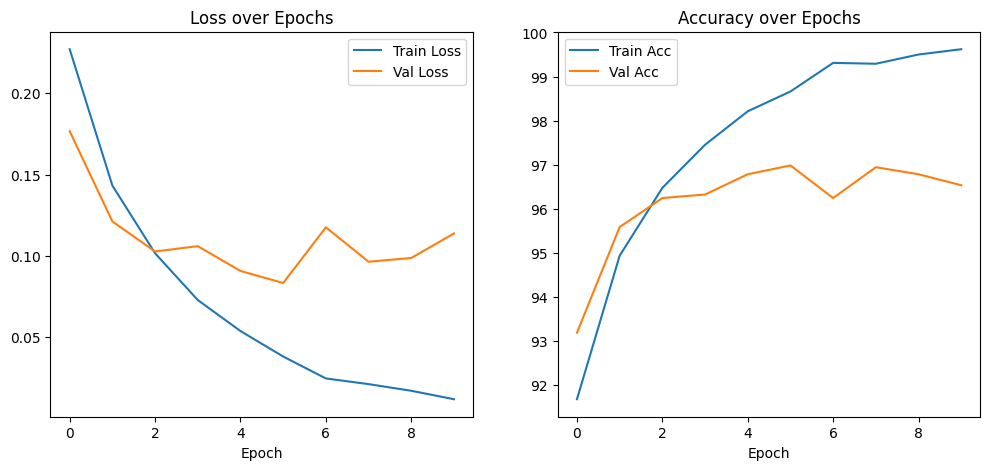

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Create a figure with two subplots
axs[0].plot(total_loss_train_plot, label='Train Loss')  # Plot training loss
axs[0].plot(total_loss_val_plot, label='Val Loss')  # Plot validation loss
axs[0].set_title('Loss over Epochs')  # Set title for loss plot
axs[0].set_xlabel('Epoch')  # Set x-axis label for loss plot
axs[0].legend()  # Show legend for loss plot

axs[1].plot(total_acc_train_plot, label='Train Acc')  # Plot training accuracy
axs[1].plot(total_acc_val_plot, label='Val Acc')  # Plot validation
axs[1].set_title('Accuracy over Epochs')  # Set title for accuracy plot
axs[1].set_xlabel('Epoch')  # Set x-axis label for accuracy plot
axs[1].legend()  # Show legend for accuracy plot

plt.show()  # Show the plots

In [60]:
# Read image
# Transform image to tensor
# predict the class of the image
# inverse transform the predicted class to get the original label

image_path = "test.webp"

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Load and convert image to RGB
    image = transform(image).unsqueeze(0).to(device)  # Apply transformations and add batch dimension, move to device
    
    print(image.shape)  # Print the shape of the transformed image tensor
    output = model(image)  # Forward pass to get predictions
    
    output = torch.argmax(output, axis=1).item()  # Return the predicted class index as an integer
    return  label_encoder.inverse_transform([output])[0]  # Return the original label corresponding to the predicted class index

In [61]:
predict_image(image_path)  # Call the function to predict the class of the image

torch.Size([1, 3, 128, 128])


'cat'